# Gate Synthesis — syntesis_1_2\n\nTest dei gate definiti in `syntesis_1_2.py` usando Bloqade/squin.

In [1]:
import sys, os, importlib
sys.path.insert(0, os.path.dirname(os.path.abspath("syntesis_1_2.py")))

import gate_syntesis_helpers, gate_syntesis
importlib.reload(gate_syntesis_helpers)
importlib.reload(gate_syntesis)

import numpy as np
from qiskit.synthesis import gridsynth_rz
from gate_syntesis import *
from bloqade import squin, tsim
from bloqade.types import Qubit
from kirin.dialects.ilist import IList
from typing import Any
import plot


Register = IList[Qubit, Any]

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

## Test gate a 1 qubit: X, Y, Z

In [2]:
@squin.kernel
def test_single_qubit_gates():
    qubits = squin.qalloc(1)
    X_gate(qubits[0])
    Y_gate(qubits[0])
    Z_gate(qubits[0])

tsim.Circuit(test_single_qubit_gates).diagram()

## Test gate a 2 qubit: CZ, SWAP

In [3]:
@squin.kernel
def test_two_qubit_gates():
    qubits = squin.qalloc(2)
    CZ_gate(qubits[0], qubits[1])
    SWAP_gate(qubits[0], qubits[1])

tsim.Circuit(test_two_qubit_gates).diagram()

## Test Toffoli (CCX) — gate a 3 qubit

In [4]:
@squin.kernel
def test_toffoli():
    qubits = squin.qalloc(3)
    Toffoli_gate(qubits[0], qubits[1], qubits[2])

tsim.Circuit(test_toffoli).diagram()

In [5]:
rz3 = Rz_gate(3)  # crea il kernel fuori da squin

@squin.kernel
def test_rz():
    qubits = squin.qalloc(1)
    rz3(qubits[0])

tsim.Circuit(test_rz).diagram(width=1200)

In [6]:
N_VALUES = range(8)
EPSILON  = 1e-5

Rz_gates = [Rz_gate(n, EPSILON) for n in N_VALUES]

for rz in Rz_gates:
    print(gate_summary(rz))
    print()

{'clifford': 4, 'T': 0, 'CNOT': 0, 'ancillas': 0}

{'clifford': 1, 'T': 0, 'CNOT': 0, 'ancillas': 0}

{'clifford': 0, 'T': 1, 'CNOT': 0, 'ancillas': 0}

{'clifford': 74, 'T': 50, 'CNOT': 0, 'ancillas': 0}

{'clifford': 82, 'T': 54, 'CNOT': 0, 'ancillas': 0}

{'clifford': 80, 'T': 52, 'CNOT': 0, 'ancillas': 0}

{'clifford': 84, 'T': 54, 'CNOT': 0, 'ancillas': 0}

{'clifford': 78, 'T': 53, 'CNOT': 0, 'ancillas': 0}



In [7]:
Rz_gates_injected = [Rz_gate_injected(n, EPSILON) for n in N_VALUES]

for rz in Rz_gates_injected:
    print(gate_summary(rz))
    print()

{'clifford': 4, 'T': 0, 'CNOT': 0, 'ancillas': 0}

{'clifford': 1, 'T': 0, 'CNOT': 0, 'ancillas': 0}

{'clifford': 2, 'T': 1, 'CNOT': 1, 'ancillas': 1}

{'clifford': 174, 'T': 50, 'CNOT': 50, 'ancillas': 50}

{'clifford': 190, 'T': 54, 'CNOT': 54, 'ancillas': 54}

{'clifford': 184, 'T': 52, 'CNOT': 52, 'ancillas': 52}

{'clifford': 192, 'T': 54, 'CNOT': 54, 'ancillas': 54}

{'clifford': 184, 'T': 53, 'CNOT': 53, 'ancillas': 53}



In [8]:
#plot.plot_gate_counts(plot.collect(range(20), 1e-20))


In [9]:
fid = gate_syntesis_helpers.statevector_fidelity(Rz_gate(50, 1e-10))
print(f"Fidelity: {fid:.10f}")

Fidelity: 1.0000000000


In [10]:
from gate_syntesis_helpers import Rz_gate_postselected, t_count_from_sequence, gate_sequence_from_circuit
from qiskit.synthesis import gridsynth_rz
import numpy as np

n = 3
rz_ps = Rz_gate_postselected(n, EPSILON)
seq = gate_sequence_from_circuit(gridsynth_rz(np.pi / 2**n, epsilon=EPSILON))
t = t_count_from_sequence(seq)

@squin.kernel
def test_postselected():
    qubits = squin.qalloc(1 + t)
    rz_ps(qubits[0], qubits[1:])

tsim.Circuit(test_postselected).diagram(width=3000)

,n,logical_T_count,postselection_success_probability_exact,dropout_probability_exact
0,0,0,1.000000e+00,0.0
1,1,0,1.000000e+00,0.0
2,2,1,5.000000e-01,0.5
3,3,101,3.944305e-31,1.0
4,4,104,4.930381e-32,1.0
5,5,100,7.888609e-31,1.0
6,6,103,9.860761e-32,1.0
7,7,102,1.972152e-31,1.0


,n,logical_T_count,shots,dropout_rate_estimated
0,0,0,0,0.000
1,1,0,0,0.000
2,2,1,200,0.485


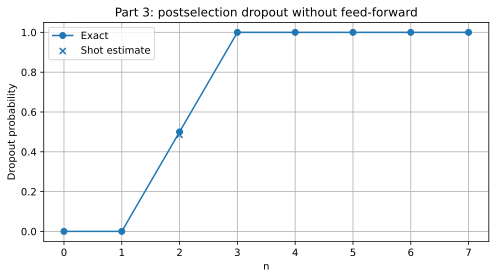

In [11]:
# ============================================================
# Part 3 — Postselection dropout without feed-forward correction
# ============================================================

import os, sys, importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bloqade.pyqrack import StackMemorySimulator

sys.path.insert(0, os.path.dirname(os.path.abspath("syntesis_1_2.py")))

import gate_syntesis; importlib.reload(gate_syntesis)
from gate_syntesis import make_postselected_dropout_kernel, t_count_from_sequence

N_VALUES      = globals().get("N_VALUES",      range(51))
PART2_EPSILON = globals().get("PART2_EPSILON", 1e-10)
RESULTS_DIR   = globals().get("RESULTS_DIR",   "results")

if "part2_circuits" not in globals() or "part2_sequences" not in globals():
    import postselection; importlib.reload(postselection)
    part2_circuits, part2_sequences = postselection.ensure_part2_results(N_VALUES, PART2_EPSILON)

# --- Exact dropout probabilities ---
rows = []
for n in N_VALUES:
    t = t_count_from_sequence(part2_sequences[n])
    rows.append({"n": n, "logical_T_count": t,
                 "postselection_success_probability_exact": 2**-t,
                 "dropout_probability_exact": 1 - 2**-t})
df_exact = pd.DataFrame(rows)
display(df_exact)

# --- Shot-based estimates (only for small T-count) ---
DROPOUT_SIM_SHOTS     = 200
MAX_SIMULATED_T_COUNT = 2

sim_rows = []
for n in N_VALUES:
    t = t_count_from_sequence(part2_sequences[n])
    if t > MAX_SIMULATED_T_COUNT:
        continue
    if t == 0:
        sim_rows.append({"n": n, "logical_T_count": t, "shots": 0, "dropout_rate_estimated": 0.0})
        continue
    kernel   = make_postselected_dropout_kernel(part2_sequences[n])
    task     = StackMemorySimulator(min_qubits=1 + t).task(kernel)
    dropouts = sum(int(task.run()) for _ in range(DROPOUT_SIM_SHOTS))
    sim_rows.append({"n": n, "logical_T_count": t,
                     "shots": DROPOUT_SIM_SHOTS, "dropout_rate_estimated": dropouts / DROPOUT_SIM_SHOTS})
df_sim = pd.DataFrame(sim_rows)
display(df_sim)

# --- Plot ---
os.makedirs(RESULTS_DIR, exist_ok=True)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_exact["n"], df_exact["dropout_probability_exact"], marker="o", label="Exact")
if not df_sim.empty:
    est = df_sim[df_sim["shots"] > 0]
    ax.scatter(est["n"], est["dropout_rate_estimated"], marker="x", label="Shot estimate")
ax.set(xlabel="n", ylabel="Dropout probability",
       title="Part 3: postselection dropout without feed-forward",
       ylim=(-0.05, 1.05))
ax.set_xticks(df_exact["n"])
ax.legend(); ax.grid(True)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "part3_postselection_dropout_probability.png"), dpi=300, bbox_inches="tight")
plt.show()

In [12]:
# ============================================================
# Part 4 - Simulate one synthesized Rz sequence on Steane [[7,1,3]]
# ============================================================

import os
import sys
import importlib

import numpy as np
from bloqade import tsim
from bloqade.pyqrack import StackMemorySimulator

sys.path.insert(0, os.getcwd())

import gate_syntesis_helpers as gate_syntesis_helpers
import gate_syntesis

importlib.reload(gate_syntesis_helpers)
importlib.reload(gate_syntesis)

from gate_syntesis import (
    make_part4_logical_fidelity_kernel_reuse_magic,
    make_part4_tsim_diagram_kernel,
    part4_logical_fidelity_qubit_count,
)
from gate_syntesis_helpers import t_count_from_sequence
import gate_syntesis_helpers as gh

PART4_N = 2

part4_sequence = tuple(part2_sequences[PART4_N])
part4_t_count  = t_count_from_sequence(part4_sequence)

print(f"Part 4 logical simulation for n={PART4_N}")
print("sequence = " + " ".join(part4_sequence).upper())
print(f"T-count  = {part4_t_count}")

# ── Circuit diagram (Stim/tsim — no dynamic feed-forward shown) ──────────────
diagram_kernel = make_part4_tsim_diagram_kernel(part4_sequence)
display(tsim.Circuit(diagram_kernel).diagram(width=1200))

# ── True simulation with feed-forward correction ──────────────────────────────
kernel               = make_part4_logical_fidelity_kernel_reuse_magic(part4_sequence)
part4_physical_qubits = part4_logical_fidelity_qubit_count(part4_sequence)

sim        = StackMemorySimulator(min_qubits=part4_physical_qubits)
data_block = sim.run(kernel)
rho_data   = sim.reduced_density_matrix(data_block)

print(f"\nphysical qubits simulated = {part4_physical_qubits}")
print(f"returned data block size  = {len(data_block)}")
print(f"reduced density matrix shape = {rho_data.shape}")
print(f"trace(rho_data) = {np.trace(rho_data)}")

# ── Fidelity against the target logical state ─────────────────────────────────

def _steane_basis_single(logical_bit):
    psi = np.zeros(2**7, dtype=complex)
    for a in (0, 1):
        for b in (0, 1):
            for c in (0, 1):
                bits = [a, b, a^b, c, a^c, b^c, a^b^c]
                if logical_bit == 1:
                    bits = [x ^ 1 for x in bits]
                idx = sum(bit << (6 - i) for i, bit in enumerate(bits))
                psi[idx] += 1.0 / np.sqrt(8)
    return psi

zero_L = _steane_basis_single(0)
one_L  = _steane_basis_single(1)

theta    = np.pi / (2 ** PART4_N)
psi_tgt  = (np.exp(-0.5j * theta) * zero_L + np.exp(0.5j * theta) * one_L) / np.sqrt(2)
fidelity = float(np.clip(np.real(np.vdot(psi_tgt, rho_data @ psi_tgt)), 0.0, 1.0))
print(f"\nLogical state fidelity vs target Rz_L(π/2^{PART4_N})|+_L⟩ = {fidelity:.10f}")

Part 4 logical simulation for n=2
sequence = T
T-count  = 1



physical qubits simulated = 14
returned data block size  = 7
reduced density matrix shape = (128, 128)
trace(rho_data) = (1.0000000641655022+0j)

Logical state fidelity vs target Rz_L(π/2^2)|+_L⟩ = 1.0000000000


In [13]:
# ============================================================
# Part 4 — Rz_L(π/2^n) con Steane_apply_logical_gate_sequence_reuse_magic
#           epsilon = 1e-10, magic block singolo riusabile
# ============================================================

import importlib
import numpy as np
import pandas as pd
from bloqade import squin
from bloqade.pyqrack import StackMemorySimulator

import gate_syntesis_helpers as gh
import gate_syntesis
importlib.reload(gh)
importlib.reload(gate_syntesis)

from gate_syntesis import (
    Steane_zero_logical_graph,
    Steane_H_logical,
    Steane_apply_logical_gate_sequence,
    Steane_apply_logical_gate_sequence_reuse_magic,
)
from qiskit.synthesis import gridsynth_rz

EPSILON_10 = 1e-10
N_REUSE    = range(6)   # cambia il range a piacere


# ── sequenza Part 2 ──────────────────────────────────────────────────────────

def _seq(n, eps=EPSILON_10):
    if n == 0: return ("s", "s")
    if n == 1: return ("s",)
    if n == 2: return ("t",)
    return gh.gate_sequence_from_circuit(gridsynth_rz(np.pi / 2**n, epsilon=eps))


# ── kernel factory ────────────────────────────────────────────────────────────

def build_reuse_kernel(sequence):
    """
    Kernel che esegue, a livello logico Steane [[7,1,3]]:
      1. logical |0⟩   via Steane_zero_logical_graph()
      2. logical |+⟩   via Steane_H_logical()
      3. magic block   squin.qalloc(7) — ripreparato come |A_L⟩ per ogni T
      4. Steane_apply_logical_gate_sequence_reuse_magic(data, magic, seq)
    """
    sequence = tuple(sequence)
    t_count  = gh.t_count_from_sequence(sequence)

    if t_count == 0:
        # Nessun gate T: il magic block non serve, usa la versione senza reuse
        @squin.kernel
        def _k():
            data_block = Steane_zero_logical_graph()   # passo 1 – logical |0⟩
            Steane_H_logical(data_block)               # passo 2 – logical |+⟩
            Steane_apply_logical_gate_sequence(data_block, [], sequence)
            return data_block
        return _k, 7

    @squin.kernel
    def _k():
        # passo 1 – prepara logical |0⟩ tramite il circuito grafo-stato Steane [[7,1,3]]
        data_block = Steane_zero_logical_graph()

        # passo 2 – applica H logico → logical |+⟩  (= H|0_L⟩)
        Steane_H_logical(data_block)

        # passo 3 – alloca UN blocco magic (7 fisici) riusabile:
        #           prima di ogni gate T verrà ripreparato come |A_L⟩ = T_L|+_L⟩
        #           e resettato a |0⟩ dopo l'iniezione, pronto per il prossimo T
        magic_block = squin.qalloc(7)

        # passo 4 – esegui la sequenza Clifford+T a livello logico con magic-state reuse
        Steane_apply_logical_gate_sequence_reuse_magic(data_block, magic_block, sequence)

        return data_block   # soli i 7 qubit del data block

    return _k, 14  # 7 data + 7 magic


# ── Steane basis states per fidelity ─────────────────────────────────────────

def _steane_basis(logical_bit):
    psi = np.zeros(2**7, dtype=complex)
    for a in (0, 1):
        for b in (0, 1):
            for c in (0, 1):
                bits = [a, b, a^b, c, a^c, b^c, a^b^c]
                if logical_bit == 1:
                    bits = [x ^ 1 for x in bits]
                idx = sum(bit << (6 - i) for i, bit in enumerate(bits))
                psi[idx] += 1.0 / np.sqrt(8)
    return psi

_ZERO_L = _steane_basis(0)
_ONE_L  = _steane_basis(1)

def _target_psi_L(theta):
    """Stato logico target dopo H_L poi Rz_L(theta): (e^{-iθ/2}|0_L⟩ + e^{iθ/2}|1_L⟩)/√2"""
    return (np.exp(-0.5j * theta) * _ZERO_L + np.exp(0.5j * theta) * _ONE_L) / np.sqrt(2)


# ── simulazione ───────────────────────────────────────────────────────────────

rows = []

for n in N_REUSE:
    theta    = np.pi / (2**n)
    sequence = _seq(n, EPSILON_10)
    t_count  = gh.t_count_from_sequence(sequence)

    seq_str  = ' '.join(sequence).upper()
    print(f"n={n}  T-count={t_count:3d}  seq={seq_str[:55]}{'…' if len(seq_str)>55 else ''}")

    kernel, n_qubits = build_reuse_kernel(sequence)
    sim              = StackMemorySimulator(min_qubits=n_qubits)
    data_block       = sim.run(kernel)
    rho              = sim.reduced_density_matrix(data_block)

    psi_tgt  = _target_psi_L(theta)
    fidelity = float(np.clip(np.real(np.vdot(psi_tgt, rho @ psi_tgt)), 0.0, 1.0))

    rows.append({
        "n":           n,
        "sequence":    seq_str,
        "T_count":     t_count,
        "phys_qubits": n_qubits,
        "fidelity":    fidelity,
        "infidelity":  max(0.0, 1.0 - fidelity),
    })
    print(f"       → fidelity = {fidelity:.10f}")

df_reuse = pd.DataFrame(rows)
display(df_reuse[["n", "T_count", "phys_qubits", "fidelity", "infidelity"]])

n=0  T-count=  0  seq=S S
       → fidelity = 0.9999998121
n=1  T-count=  0  seq=S
       → fidelity = 0.9999994581
n=2  T-count=  1  seq=T
       → fidelity = 0.9999998548
n=3  T-count=101  seq=S H T S H T H T H T H T S H T H T H T S H T H T S H T S…
       → fidelity = 0.9999996224
n=4  T-count=104  seq=T S H T H T H T H T S H T H T S H T H T H T H T H T S H…
       → fidelity = 0.9619392307
n=5  T-count=100  seq=H T S H T S H T H T H T S H T H T S H T S H T H T H T S…
       → fidelity = 0.9999998485


,n,T_count,phys_qubits,fidelity,infidelity
0,0,0,7,1.000000,1.879431e-07
1,1,0,7,0.999999,5.418967e-07
2,2,1,14,1.000000,1.451520e-07
3,3,101,14,1.000000,3.776423e-07
4,4,104,14,0.961939,3.806077e-02
5,5,100,14,1.000000,1.514559e-07


Simulating Part 4 n=0, T-count=0, shots=10
Simulating Part 4 n=1, T-count=0, shots=10
Simulating Part 4 n=2, T-count=1, shots=10
Simulating Part 4 n=3, T-count=101, shots=10
Simulating Part 4 n=4, T-count=104, shots=10
Simulating Part 4 n=5, T-count=100, shots=10


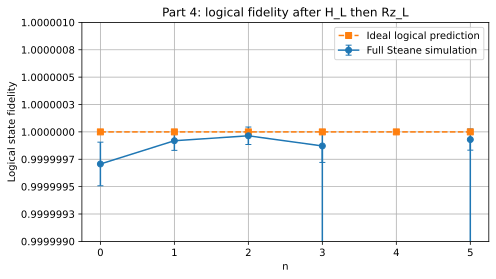

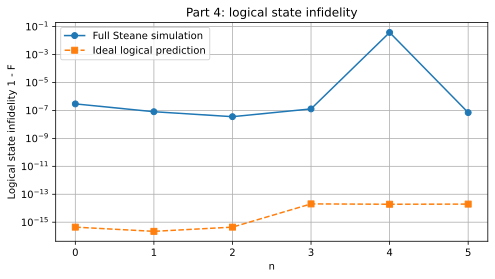

In [14]:
# ============================================================
# Part 4 - Logical-state fidelity on Steane [[7,1,3]]
# ============================================================

import os
import sys
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bloqade.pyqrack import StackMemorySimulator

sys.path.insert(0, os.getcwd())

import gate_syntesis_helpers as gh
import gate_syntesis

importlib.reload(gh)
importlib.reload(gate_syntesis)

from gate_syntesis import (
    make_part4_logical_fidelity_kernel_reuse_magic,
    part4_logical_fidelity_qubit_count,
)


PART4_FIDELITY_N_VALUES = range(6)
PART4_FIDELITY_SHOTS = 10


def get_part4_sequence(n: int):
    if "part2_sequences" in globals() and n in part2_sequences:
        return tuple(part2_sequences[n])

    if "part2_rz_sequence" in globals():
        epsilon = globals().get("PART2_EPSILON", globals().get("EPSILON", 1e-4))
        return tuple(part2_rz_sequence(n, epsilon))

    raise NameError(
        "part2_sequences is not defined. Run the Part 2 sequence cell before this cell."
    )


def steane_basis_state(logical_bit: int):
    # Return |0_L> or |1_L> in the basis order used by reduced_density_matrix.
    psi = np.zeros(2**7, dtype=complex)

    for a in (0, 1):
        for b in (0, 1):
            for c in (0, 1):
                bits = [a, b, a ^ b, c, a ^ c, b ^ c, a ^ b ^ c]

                if logical_bit == 1:
                    bits = [bit ^ 1 for bit in bits]

                # PyQrack reduced_density_matrix uses big-endian matrix order
                # for the qubit list [q0, ..., q6].
                index = sum(bit << (6 - i) for i, bit in enumerate(bits))
                psi[index] += 1 / np.sqrt(8)

    return psi


ZERO_L = steane_basis_state(0)
ONE_L = steane_basis_state(1)


def target_logical_state_after_H_then_Rz(theta: float):
    return (
        np.exp(-0.5j * theta) * ZERO_L
        + np.exp(0.5j * theta) * ONE_L
    ) / np.sqrt(2)


def pure_state_fidelity_from_rho(rho, psi):
    value = np.vdot(psi, rho @ psi)
    return float(np.clip(np.real(value), 0.0, 1.0))


def ideal_logical_state_fidelity_from_sequence(theta: float, sequence):
    # Ideal logical-level prediction for the same synthesized Clifford+T sequence.
    psi0 = np.array([1, 0], dtype=complex)
    psi_after_h = gh.H @ psi0
    psi_target = gh.Rz(theta) @ psi_after_h
    psi_sequence = gh.unitary_from_gate_sequence(sequence) @ psi_after_h
    fidelity = abs(np.vdot(psi_target, psi_sequence)) ** 2
    return float(np.clip(np.real(fidelity), 0.0, 1.0))


rows = []

for n in PART4_FIDELITY_N_VALUES:
    theta = np.pi / (2**n)
    sequence = get_part4_sequence(n)
    t_count = gh.t_count_from_sequence(sequence)

    print(f"Simulating Part 4 n={n}, T-count={t_count}, shots={PART4_FIDELITY_SHOTS}")

    kernel = make_part4_logical_fidelity_kernel_reuse_magic(sequence)
    physical_qubits_simulated = part4_logical_fidelity_qubit_count(sequence)
    psi_target_logical = target_logical_state_after_H_then_Rz(theta)

    fidelities = []
    for _ in range(PART4_FIDELITY_SHOTS):
        sim = StackMemorySimulator(min_qubits=physical_qubits_simulated)
        data_block = sim.run(kernel)
        rho_data = sim.reduced_density_matrix(data_block)
        fidelities.append(pure_state_fidelity_from_rho(rho_data, psi_target_logical))

    mean_fidelity = float(np.mean(fidelities))
    std_fidelity = float(np.std(fidelities))
    ideal_fidelity = ideal_logical_state_fidelity_from_sequence(theta, sequence)

    rows.append(
        {
            "n": n,
            "target": f"H_L then Rz_L(pi/2^{n})",
            "Rz_sequence": " ".join(sequence).upper(),
            "T_or_Tdg_count": t_count,
            "physical_qubits_simulated": physical_qubits_simulated,
            "shots": PART4_FIDELITY_SHOTS,
            "steane_state_fidelity_mean": mean_fidelity,
            "steane_state_fidelity_std": std_fidelity,
            "steane_state_infidelity_mean": max(0.0, 1.0 - mean_fidelity),
            "ideal_logical_state_fidelity": ideal_fidelity,
            "ideal_logical_state_infidelity": max(0.0, 1.0 - ideal_fidelity),
        }
    )


df_part4_logical_fidelity = pd.DataFrame(rows)
#display(df_part4_logical_fidelity)

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(
    df_part4_logical_fidelity["n"],
    df_part4_logical_fidelity["steane_state_fidelity_mean"],
    yerr=df_part4_logical_fidelity["steane_state_fidelity_std"],
    marker="o",
    capsize=3,
    label="Full Steane simulation",
)
ax.plot(
    df_part4_logical_fidelity["n"],
    df_part4_logical_fidelity["ideal_logical_state_fidelity"],
    marker="s",
    linestyle="--",
    label="Ideal logical prediction",
)
ax.set_xlabel("n")
ax.set_ylabel("Logical state fidelity")
ax.set_title("Part 4: logical fidelity after H_L then Rz_L")
ax.set_xticks(list(PART4_FIDELITY_N_VALUES))
ax.set_ylim(0.999999, 1.000001)
ax.ticklabel_format(axis="y", style="plain", useOffset=False)
ax.yaxis.set_major_formatter(plt.FormatStrFormatter("%.7f"))
ax.legend()
ax.grid(True)
fig.tight_layout()
plt.show()

positive_steane_infidelity = df_part4_logical_fidelity["steane_state_infidelity_mean"].replace(0.0, np.nan)
positive_ideal_infidelity = df_part4_logical_fidelity["ideal_logical_state_infidelity"].replace(0.0, np.nan)

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(
    df_part4_logical_fidelity["n"],
    positive_steane_infidelity,
    marker="o",
    label="Full Steane simulation",
)
ax.semilogy(
    df_part4_logical_fidelity["n"],
    positive_ideal_infidelity,
    marker="s",
    linestyle="--",
    label="Ideal logical prediction",
)
ax.set_xlabel("n")
ax.set_ylabel("Logical state infidelity 1 - F")
ax.set_title("Part 4: logical state infidelity")
ax.set_xticks(list(PART4_FIDELITY_N_VALUES))
ax.legend()
ax.grid(True)
fig.tight_layout()
plt.show()

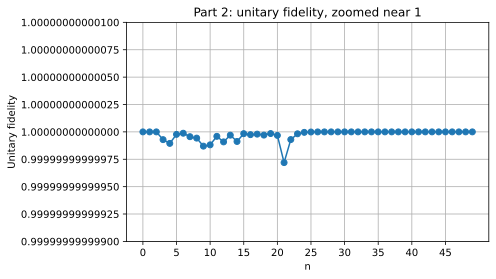

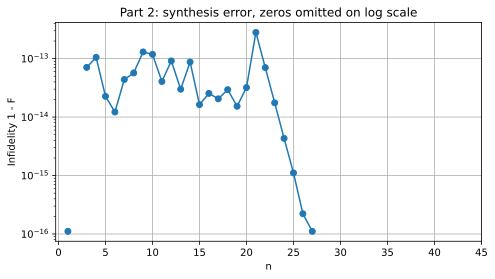

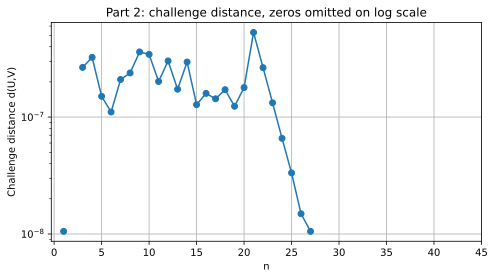

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from qiskit.synthesis import gridsynth_rz

import gate_syntesis_helpers as gh


EPSILON = 1e-6
N_VALUES = range(50)


def matrix_gate_distance(U, V):
    value = 1 - abs(np.trace(U.conj().T @ V)) / 2
    return np.sqrt(max(0.0, float(np.real(value))))


def safe_gridsynth_rz_sequence(theta: float, epsilon: float):
    target = gh.Rz(theta)

    # For coarse tolerances, the identity circuit can already be a valid
    # approximation. This also avoids a known gridsynth_rz panic at epsilon=1e-1.
    if matrix_gate_distance(target, gh.I) <= epsilon:
        return ()

    # If the Rust gridsynth backend panics for a coarse epsilon, retry with a
    # stricter tolerance. A stricter approximation is still valid for the
    # original epsilon.
    candidate_epsilons = [epsilon, 1e-3, 1e-4, 1e-6, 1e-10]
    tried = set()

    for eps_try in candidate_epsilons:
        if eps_try in tried or eps_try > epsilon:
            continue

        tried.add(eps_try)

        try:
            qiskit_circuit = gridsynth_rz(theta, epsilon=eps_try)
        except BaseException as exc:
            if type(exc)._name_ != "PanicException":
                raise
            continue

        sequence = gh.gate_sequence_from_circuit(qiskit_circuit)
        distance = matrix_gate_distance(target, gh.unitary_from_gate_sequence(sequence))

        if distance <= epsilon + 1e-15:
            return sequence

    raise RuntimeError(
        f"Could not synthesize Rz({theta}) within epsilon={epsilon} without gridsynth_rz failing."
    )


def part2_rz_sequence(n: int, epsilon: float = EPSILON):
    # Exact cases.
    if n == 0:
        return ("s", "s")   # Rz(pi) = Z = S^2 up to global phase

    if n == 1:
        return ("s",)       # Rz(pi/2) = S up to global phase

    if n == 2:
        return ("t",)       # Rz(pi/4) = T up to global phase

    # Approximate cases.
    theta = np.pi / (2 ** n)
    return safe_gridsynth_rz_sequence(theta, epsilon)


def unitary_fidelity(U, V):
    value = abs(np.trace(U.conj().T @ V)) / 2

    # The physical fidelity is in [0, 1]. Tiny excursions above 1 come only
    # from floating-point roundoff and make the plot look misleading.
    return float(np.clip(np.real(value), 0.0, 1.0))


def safe_gate_distance(U, V):
    fidelity = unitary_fidelity(U, V)
    value = max(0.0, 1.0 - fidelity)
    return np.sqrt(value)


def sparse_n_ticks(values, step=5):
    values = list(values)
    if len(values) <= 15:
        return values
    return values[::step]


def disable_y_offset(ax):
    formatter = ScalarFormatter(useOffset=False)
    formatter.set_scientific(False)
    ax.yaxis.set_major_formatter(formatter)


rows = []

for n in N_VALUES:
    theta = np.pi / (2 ** n)

    sequence = part2_rz_sequence(n, EPSILON)

    U_target = gh.Rz(theta)
    V_circuit = gh.unitary_from_gate_sequence(sequence)

    fidelity = unitary_fidelity(U_target, V_circuit)
    distance = safe_gate_distance(U_target, V_circuit)
    infidelity = max(0.0, 1.0 - fidelity)

    rows.append(
        {
            "n": n,
            "target": f"Rz(pi/2^{n})",
            "theta": theta,
            "sequence": " ".join(sequence).upper(),
            "gate_count": len(sequence),
            "T_or_Tdg_count": gh.t_count_from_sequence(sequence),
            "unitary_fidelity": fidelity,
            "challenge_distance": distance,
            "infidelity": infidelity,
        }
    )


df_p2_fidelity = pd.DataFrame(rows)
#display(df_p2_fidelity)


plt.figure(figsize=(7, 4))
plt.plot(df_p2_fidelity["n"], df_p2_fidelity["unitary_fidelity"], marker="o")
plt.xlabel("n")
plt.ylabel("Unitary fidelity")
plt.title("Part 2: unitary fidelity, zoomed near 1")
plt.xticks(sparse_n_ticks(N_VALUES))
plt.ylim(0.999999999999, 1.000000000001)
disable_y_offset(plt.gca())
plt.grid(True)
plt.tight_layout()
plt.show()


positive_infidelity = df_p2_fidelity["infidelity"].replace(0.0, np.nan)

plt.figure(figsize=(7, 4))
plt.semilogy(df_p2_fidelity["n"], positive_infidelity, marker="o")
plt.xlabel("n")
plt.ylabel("Infidelity 1 - F")
plt.title("Part 2: synthesis error, zeros omitted on log scale")
plt.xticks(sparse_n_ticks(N_VALUES))
plt.grid(True)
plt.tight_layout()
plt.show()


positive_distance = df_p2_fidelity["challenge_distance"].replace(0.0, np.nan)

plt.figure(figsize=(7, 4))
plt.semilogy(df_p2_fidelity["n"], positive_distance, marker="o")
plt.xlabel("n")
plt.ylabel("Challenge distance d(U,V)")
plt.title("Part 2: challenge distance, zeros omitted on log scale")
plt.xticks(sparse_n_ticks(N_VALUES))
plt.grid(True)
plt.tight_layout()
plt.show()

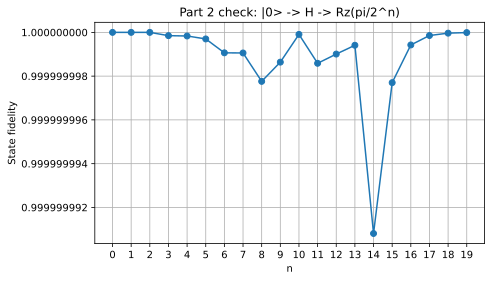

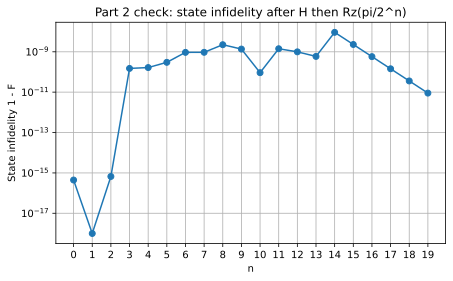

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit.synthesis import gridsynth_rz
from qiskit.quantum_info import Statevector, state_fidelity

import gate_syntesis_helpers as gh


EPSILON = 1e-4
N_VALUES = range(20)


def matrix_gate_distance(U, V):
    value = 1 - abs(np.trace(U.conj().T @ V)) / 2
    return np.sqrt(max(0.0, float(np.real(value))))


def safe_gridsynth_rz_sequence(theta: float, epsilon: float):
    target = gh.Rz(theta)

    # For coarse tolerances, the identity circuit can already be a valid
    # approximation. This also avoids a known gridsynth_rz panic at epsilon=1e-1.
    if matrix_gate_distance(target, gh.I) <= epsilon:
        return ()

    # If the Rust gridsynth backend panics for a coarse epsilon, retry with a
    # stricter tolerance. A stricter approximation is still valid for the
    # original epsilon.
    candidate_epsilons = [epsilon, 1e-3, 1e-4, 1e-6, 1e-10]
    tried = set()

    for eps_try in candidate_epsilons:
        if eps_try in tried or eps_try > epsilon:
            continue

        tried.add(eps_try)

        try:
            qiskit_circuit = gridsynth_rz(theta, epsilon=eps_try)
        except BaseException as exc:
            if type(exc)._name_ != "PanicException":
                raise
            continue

        sequence = gh.gate_sequence_from_circuit(qiskit_circuit)
        distance = matrix_gate_distance(target, gh.unitary_from_gate_sequence(sequence))

        if distance <= epsilon + 1e-15:
            return sequence

    raise RuntimeError(
        f"Could not synthesize Rz({theta}) within epsilon={epsilon} without gridsynth_rz failing."
    )


def part2_rz_sequence(n: int, epsilon: float = EPSILON):
    """
    Return the Clifford+T sequence used in Part 2 for Rz(pi/2^n).
    The first three cases are exact.
    """
    if n == 0:
        return ("s", "s")   # Rz(pi) = Z = S^2 up to global phase

    if n == 1:
        return ("s",)       # Rz(pi/2) = S up to global phase

    if n == 2:
        return ("t",)       # Rz(pi/4) = T up to global phase

    theta = np.pi / (2 ** n)
    return safe_gridsynth_rz_sequence(theta, epsilon)


psi0 = np.array([1, 0], dtype=complex)
psi_after_H = gh.H @ psi0

rows = []

for n in N_VALUES:
    theta = np.pi / (2 ** n)

    rz_sequence = part2_rz_sequence(n, EPSILON)

    U_target = gh.Rz(theta)
    V_synthesized = gh.unitary_from_gate_sequence(rz_sequence)

    psi_target = U_target @ psi_after_H
    psi_synthesized = V_synthesized @ psi_after_H

    fidelity = state_fidelity(
        Statevector(psi_target),
        Statevector(psi_synthesized),
    )

    rows.append(
        {
            "n": n,
            "target": f"H then Rz(pi/2^{n})",
            "part2_sequence_after_H": " ".join(("h",) + rz_sequence).upper(),
            "Rz_sequence": " ".join(rz_sequence).upper(),
            "T_or_Tdg_count": gh.t_count_from_sequence(rz_sequence),
            "state_fidelity": fidelity,
            "state_infidelity": 1 - fidelity,
        }
    )


df_H_then_Rz_state_fidelity = pd.DataFrame(rows)
#display(df_H_then_Rz_state_fidelity)


plt.figure(figsize=(7, 4))
plt.plot(
    df_H_then_Rz_state_fidelity["n"],
    df_H_then_Rz_state_fidelity["state_fidelity"],
    marker="o",
)
plt.xlabel("n")
plt.ylabel("State fidelity")
plt.title("Part 2 check: |0> -> H -> Rz(pi/2^n)")
plt.xticks(list(N_VALUES))
plt.grid(True)
plt.ticklabel_format(axis="y", style="plain", useOffset=False)
plt.show()


plt.figure(figsize=(7, 4))
plt.semilogy(
    df_H_then_Rz_state_fidelity["n"],
    df_H_then_Rz_state_fidelity["state_infidelity"].clip(lower=1e-18),
    marker="o",
)
plt.xlabel("n")
plt.ylabel("State infidelity 1 - F")
plt.title("Part 2 check: state infidelity after H then Rz(pi/2^n)")
plt.xticks(list(N_VALUES))
plt.grid(True)
plt.show()

In [17]:
import importlib, bloch_video
importlib.reload(bloch_video)
from bloch_video import make_bloch_video

# n=3  →  ~135-gate sequence (T-count≈45), video ~25 s
# n=2  →  2-gate sequence (H, T), very short demo
BLOCH_N       = 3      # change to any n you like
BLOCH_EPSILON = 1e-5   # gridsynth approximation tolerance

out = make_bloch_video(
    n           = BLOCH_N,
    epsilon     = BLOCH_EPSILON,
    output_dir  = RESULTS_DIR,
    n_interp    = 8,    # frames per gate transition
    hold_frames = 3,    # pause frames after each gate lands
    fps         = 24,
)
print("Video saved:", out)

# Show inline preview (first frame as static image)
from IPython.display import Video, display as ipy_display
ipy_display(Video(out, width=640))

n=3  θ=π/2^3  sequence length=126  T-count=50
Total animation frames: 1386  (57.8 s at 24 fps)
Saved → results/bloch_sphere_part2_n3.mp4
Video saved: results/bloch_sphere_part2_n3.mp4
